# Titanic Survival Prediction using K-Nearest Neighbors (KNN)

**Name: ** Shafikul Islam Marwan   
**Roll: ** 220121  

**What we will do:**
- Load data directly from GitHub (no manual upload needed)
- Preprocess and clean the data
- Use the elbow method to explore how K affects error rate
- Tune hyperparameters using GridSearchCV
- Evaluate with confusion matrix, ROC curve, and multiple metrics
- Visualize the 2D decision boundary using PCA

## 1. Install and Import Libraries

In [4]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
from sklearn.decomposition import PCA

print('All libraries imported.')

All libraries imported.


## 2. Data Loading

The dataset is fetched directly from GitHub using the raw URL. Replace `YOUR_USERNAME` and `YOUR_REPO` with your actual values before running.

> Make sure the repository is public and the CSV files are in the `main` branch.

In [6]:
TRAIN_URL = 'Titanic_train.csv'
TEST_URL  = 'Titanic_test.csv'

train_df = pd.read_csv(TRAIN_URL)
test_df  = pd.read_csv(TEST_URL)

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)
train_df.head()

Train shape: (891, 12)
Test shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Exploratory Data Analysis

A quick look at the data structure, missing values, and target distribution.

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
print('Missing values in training data:')
print(train_df.isnull().sum())

Missing values in training data:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


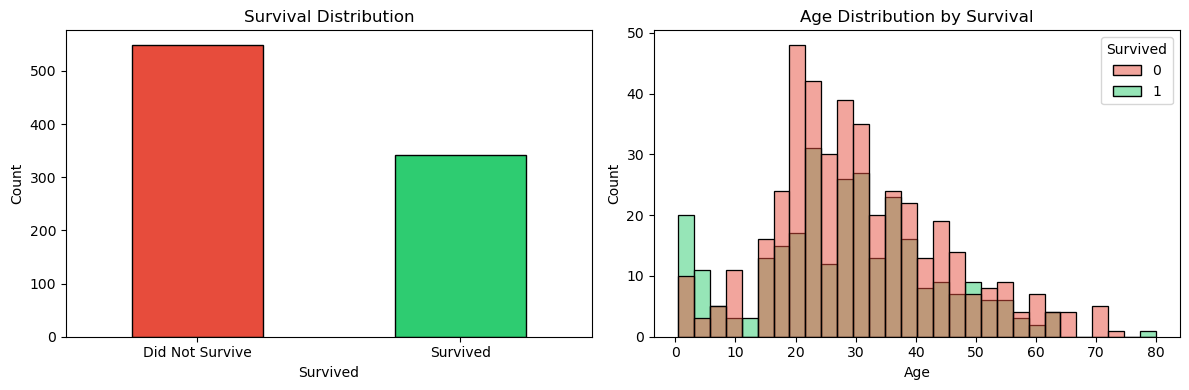

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['Survived'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#e74c3c', '#2ecc71'], edgecolor='black'
)
axes[0].set_title('Survival Distribution')
axes[0].set_xticklabels(['Did Not Survive', 'Survived'], rotation=0)
axes[0].set_ylabel('Count')

sns.histplot(
    data=train_df, x='Age', hue='Survived',
    bins=30, ax=axes[1], palette=['#e74c3c', '#2ecc71']
)
axes[1].set_title('Age Distribution by Survival')

plt.tight_layout()
plt.show()

## 4. Preprocessing

KNN is a distance-based algorithm so preprocessing matters a lot. Steps:
- Drop columns with no useful signal (Name, Ticket, Cabin, PassengerId)
- Fill missing Age and Fare with median, Embarked with mode
- Label encode Sex, one-hot encode Embarked
- Scale all features with StandardScaler

In [10]:
def preprocess(df):
    df = df.copy()

    drop_cols = ['Name', 'Ticket', 'Cabin', 'PassengerId']
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    df['Age'].fillna(df['Age'].median(), inplace=True)
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
    df['Fare'].fillna(df['Fare'].median(), inplace=True)

    df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
    df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

    return df

train_clean = preprocess(train_df)
print('Shape after preprocessing:', train_clean.shape)
train_clean.head()

Shape after preprocessing: (891, 9)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


## 5. Train / Validation / Test Split

We split the labeled data 70% for training, 15% for validation, and 15% for the final test. Stratification ensures class balance is preserved in all splits.

In [11]:
X = train_clean.drop('Survived', axis=1)
y = train_clean['Survived']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train size : {X_train.shape[0]}')
print(f'Val size   : {X_val.shape[0]}')
print(f'Test size  : {X_test.shape[0]}')

Train size : 623
Val size   : 134
Test size  : 134


In [12]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

## 6. Elbow Method (Error Rate vs. K)

We loop over K values from 1 to 30 and measure the validation error rate for each. The elbow point helps us decide a reasonable starting range for K before doing a full grid search.

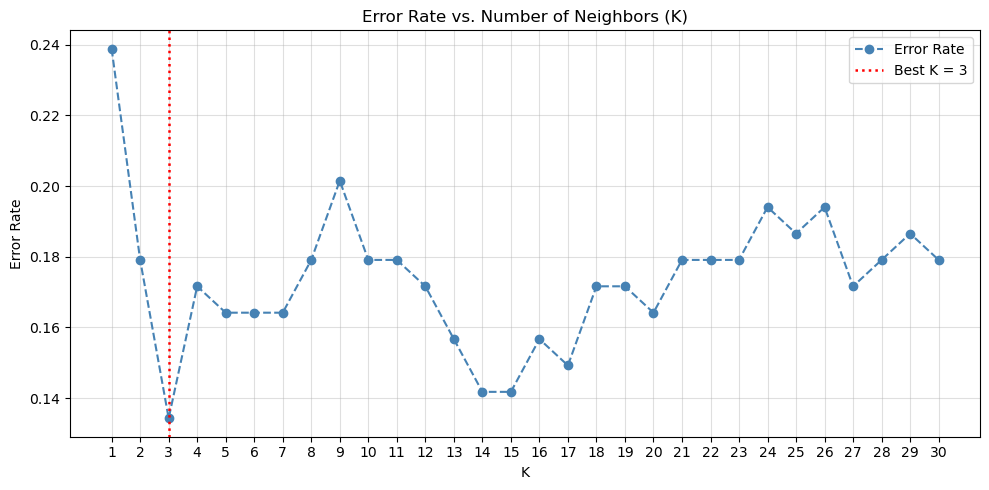

Lowest validation error at K = 3


In [13]:
error_rates = []
k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    preds = knn.predict(X_val_sc)
    error_rates.append(1 - accuracy_score(y_val, preds))

best_k = list(k_range)[np.argmin(error_rates)]

plt.figure(figsize=(10, 5))
plt.plot(
    list(k_range), error_rates, marker='o',
    linestyle='--', color='steelblue', markersize=6, label='Error Rate'
)
plt.axvline(x=best_k, color='red', linestyle=':', linewidth=1.8, label=f'Best K = {best_k}')
plt.title('Error Rate vs. Number of Neighbors (K)')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.xticks(list(k_range))
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Lowest validation error at K = {best_k}')

## 7. Hyperparameter Tuning with GridSearchCV

We do a systematic search over three parameters:
- **n_neighbors (K):** How many neighbors to vote
- **weights:** `uniform` (all neighbors equal) vs `distance` (closer neighbors weighted more)
- **metric:** Distance function: euclidean, manhattan, or minkowski

5-fold cross-validation is used on the training set to avoid overfitting to the validation set.

In [14]:
param_grid = {
    'n_neighbors': list(range(3, 20, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_sc, y_train)

print('Best Parameters:', grid_search.best_params_)
print(f'Best CV Accuracy: {grid_search.best_score_:.4f}')

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 13, 'weights': 'uniform'}
Best CV Accuracy: 0.8153


## 8. Training the Final Model

We use the best parameters found above to evaluate on the validation set first.

In [15]:
best_knn = grid_search.best_estimator_

val_acc = accuracy_score(y_val, best_knn.predict(X_val_sc))
print(f'Validation Accuracy: {val_acc:.4f}')

Validation Accuracy: 0.8433


## 9. Evaluation on Test Set

Now we evaluate the final model on the held-out test set. We report accuracy, precision, recall, F1, and AUC.

In [16]:
y_pred = best_knn.predict(X_test_sc)
y_prob = best_knn.predict_proba(X_test_sc)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print('---------- Test Set Metrics ----------')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1 Score  : {f1:.4f}')
print(f'AUC       : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

---------- Test Set Metrics ----------
Accuracy  : 0.7761
Precision : 0.7333
Recall    : 0.6471
F1 Score  : 0.6875
AUC       : 0.8280

              precision    recall  f1-score   support

Not Survived       0.80      0.86      0.83        83
    Survived       0.73      0.65      0.69        51

    accuracy                           0.78       134
   macro avg       0.77      0.75      0.76       134
weighted avg       0.77      0.78      0.77       134



### 9.1 Confusion Matrix

Shows how many predictions were correct and where the model got confused.

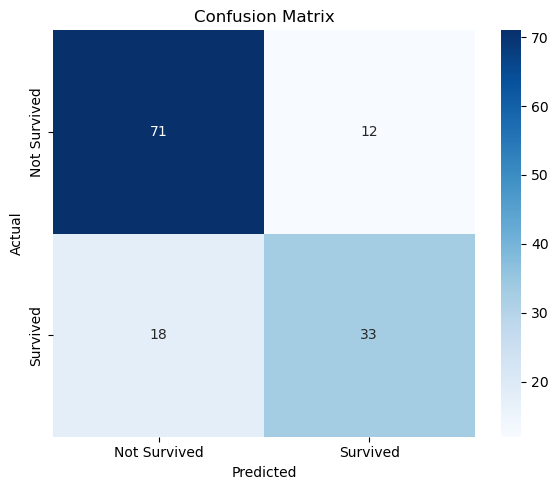

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### 9.2 ROC Curve

The ROC curve shows the trade-off between true positive rate and false positive rate across thresholds. A higher AUC score means better overall discrimination ability.

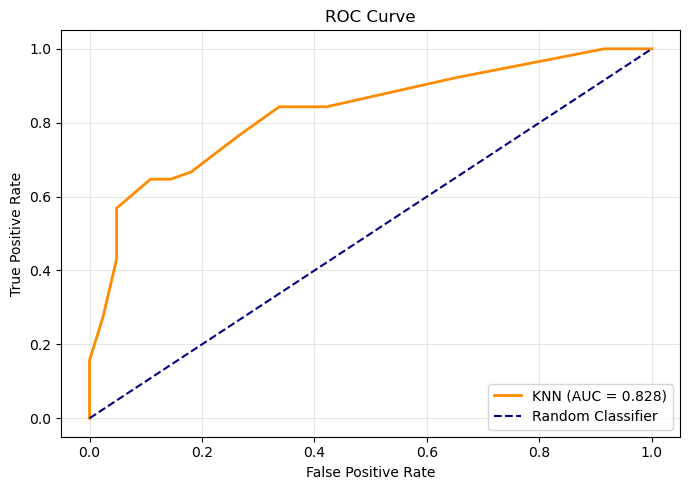

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'KNN (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. 2D Decision Boundary

Our feature space has multiple dimensions, so we use PCA to reduce it to 2 principal components. We then train a KNN on the 2D data and visualize the resulting decision regions.

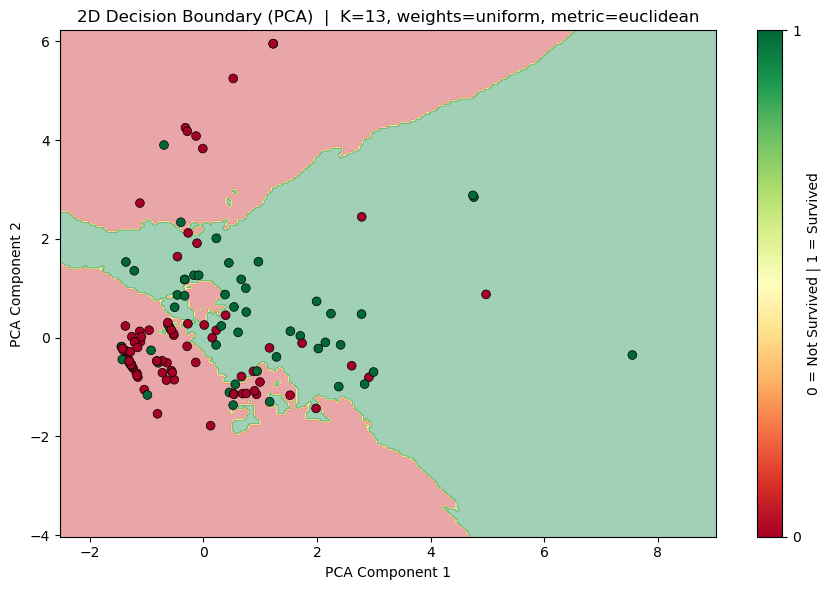

In [19]:
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_sc)
X_test_2d  = pca.transform(X_test_sc)

bp = grid_search.best_params_
knn_2d = KNeighborsClassifier(
    n_neighbors=bp['n_neighbors'],
    weights=bp['weights'],
    metric=bp['metric']
)
knn_2d.fit(X_train_2d, y_train)

h = 0.05
x_min = X_train_2d[:, 0].min() - 1
x_max = X_train_2d[:, 0].max() + 1
y_lo  = X_train_2d[:, 1].min() - 1
y_hi  = X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_lo, y_hi, h))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlGn')
sc = plt.scatter(
    X_test_2d[:, 0], X_test_2d[:, 1],
    c=y_test, cmap='RdYlGn',
    edgecolors='black', s=40, linewidths=0.5
)
plt.colorbar(sc, ticks=[0, 1], label='0 = Not Survived | 1 = Survived')
plt.title(
    f'2D Decision Boundary (PCA)  |  K={bp["n_neighbors"]}, '
    f'weights={bp["weights"]}, metric={bp["metric"]}'
)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

## 11. Summary

We built a full KNN classification pipeline on the Titanic dataset from scratch. Here is a recap:

| Step | Details |
|------|---------|
| Dataset | Titanic (loaded from GitHub) |
| Preprocessing | Imputation, label/one-hot encoding, StandardScaler |
| Split | 70% train / 15% val / 15% test (stratified) |
| Elbow Plot | Swept K from 1 to 30 on the validation set |
| Grid Search | Searched K, weights, metric with 5-fold CV |
| Metrics | Accuracy, Precision, Recall, F1, AUC |
| Visualizations | Elbow plot, confusion matrix, ROC curve, 2D decision boundary |

The final model was selected based on cross-validated accuracy and evaluated on the held-out test set.